In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, roc_curve
import warnings
import gc
import os
from scipy import stats

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Define data path
DATA_PATH = '~/fraud_det/dataset/'

# Load transaction data
print("Loading transaction data...")
train_transaction = pd.read_csv(os.path.join(DATA_PATH, 'train_transaction.csv'))
test_transaction = pd.read_csv(os.path.join(DATA_PATH, 'test_transaction.csv'))

# Load identity data
print("Loading identity data...")
train_identity = pd.read_csv(os.path.join(DATA_PATH, 'train_identity.csv'))
test_identity = pd.read_csv(os.path.join(DATA_PATH, 'test_identity.csv'))

print(f"\nTrain Transaction Shape: {train_transaction.shape}")
print(f"Test Transaction Shape: {test_transaction.shape}")
print(f"Train Identity Shape: {train_identity.shape}")
print(f"Test Identity Shape: {test_identity.shape}")

Loading transaction data...
Loading identity data...

Train Transaction Shape: (590540, 394)
Test Transaction Shape: (506691, 393)
Train Identity Shape: (144233, 41)
Test Identity Shape: (141907, 41)


In [3]:
# Merge transaction and identity data on TransactionID
train = train_transaction.merge(train_identity, on='TransactionID', how='left')
test = test_transaction.merge(test_identity, on='TransactionID', how='left')

print(f"Train Shape after merge: {train.shape}")
print(f"Test Shape after merge: {test.shape}")

# Free memory
del train_transaction, test_transaction, train_identity, test_identity
gc.collect()

Train Shape after merge: (590540, 434)
Test Shape after merge: (506691, 433)


0

Target Distribution:
isFraud
0    569877
1     20663
Name: count, dtype: int64

Fraud Rate: 3.50%


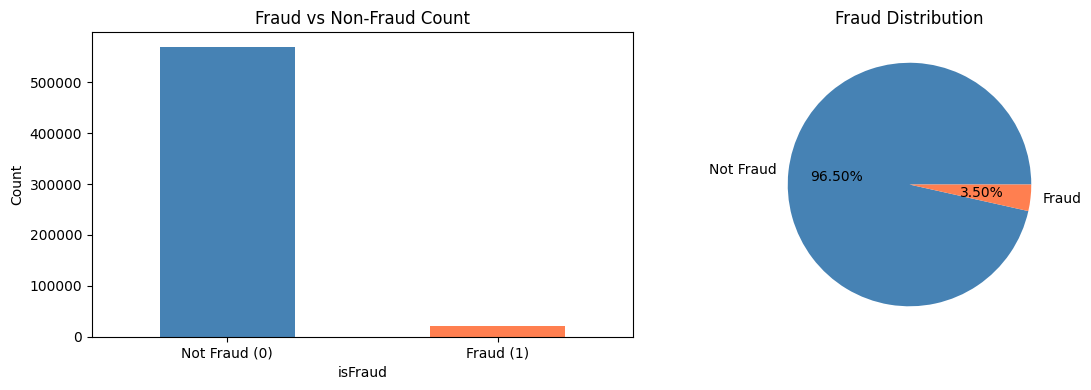


Column Categories:
- C columns (counting): ['C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14']
- D columns (timedelta): ['D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D9', 'D10', 'D11', 'D12', 'D13', 'D14', 'D15', 'DeviceType', 'DeviceInfo']
- M columns (match): ['M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9']
- V columns (Vesta features): 339 columns
- id columns: ['id_01', 'id_02', 'id_03', 'id_04', 'id_05', 'id_06', 'id_07', 'id_08', 'id_09', 'id_10', 'id_11', 'id_12', 'id_13', 'id_14', 'id_15', 'id_16', 'id_17', 'id_18', 'id_19', 'id_20', 'id_21', 'id_22', 'id_23', 'id_24', 'id_25', 'id_26', 'id_27', 'id_28', 'id_29', 'id_30', 'id_31', 'id_32', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38']


In [4]:
print("Target Distribution:")
print(train['isFraud'].value_counts())
print(f"\nFraud Rate: {train['isFraud'].mean() * 100:.2f}%")

# Visualize target distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

train['isFraud'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'coral'])
axes[0].set_title('Fraud vs Non-Fraud Count')
axes[0].set_xlabel('isFraud')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['Not Fraud (0)', 'Fraud (1)'], rotation=0)

train['isFraud'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.2f%%', 
                                     colors=['steelblue', 'coral'], labels=['Not Fraud', 'Fraud'])
axes[1].set_title('Fraud Distribution')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

# Column categories
print("\nColumn Categories:")
print(f"- C columns (counting): {[c for c in train.columns if c.startswith('C')]}")
print(f"- D columns (timedelta): {[c for c in train.columns if c.startswith('D')]}")
print(f"- M columns (match): {[c for c in train.columns if c.startswith('M')]}")
print(f"- V columns (Vesta features): {len([c for c in train.columns if c.startswith('V')])} columns")
print(f"- id columns: {[c for c in train.columns if c.startswith('id_')]}")


In [5]:
def reduce_mem_usage(df, verbose=True):
    """Reduce memory usage by converting data types (safe version)"""
    start_mem = df.memory_usage(deep=True).sum() / 1024**2

    for col in df.columns:
        col_type = df[col].dtype

        # Skip non-numeric columns safely
        if not pd.api.types.is_numeric_dtype(col_type):
            continue

        # Coerce to numeric to avoid string contamination
        col_data = pd.to_numeric(df[col], errors="coerce")

        if col_data.isna().all():
            # Column is completely unusable for numeric downcasting
            continue

        c_min = col_data.min()
        c_max = col_data.max()

        # Integer types
        if pd.api.types.is_integer_dtype(col_type):
            if c_min >= np.iinfo(np.int8).min and c_max <= np.iinfo(np.int8).max:
                df[col] = col_data.astype(np.int8)
            elif c_min >= np.iinfo(np.int16).min and c_max <= np.iinfo(np.int16).max:
                df[col] = col_data.astype(np.int16)
            elif c_min >= np.iinfo(np.int32).min and c_max <= np.iinfo(np.int32).max:
                df[col] = col_data.astype(np.int32)
            else:
                df[col] = col_data.astype(np.int64)

        # Float types
        else:
            if c_min >= np.finfo(np.float32).min and c_max <= np.finfo(np.float32).max:
                df[col] = col_data.astype(np.float32)
            else:
                df[col] = col_data.astype(np.float64)

    end_mem = df.memory_usage(deep=True).sum() / 1024**2
    if verbose:
        print(
            f"Memory usage: {start_mem:.2f} MB -> {end_mem:.2f} MB "
            f"({100 * (start_mem - end_mem) / start_mem:.1f}% reduction)"
        )

    return df


In [6]:
def create_transaction_amount_features(df):
    """Create features based on transaction amount"""
    print("Creating transaction amount features...")
    
    # Log transformation
    df['TransactionAmt_Log'] = np.log1p(df['TransactionAmt'])
    
    # Decimal part (cents) - often fraudsters use round numbers
    df['TransactionAmt_decimal'] = ((df['TransactionAmt'] - df['TransactionAmt'].astype(int)) * 1000).astype(int)
    
    # Is round amount (no cents)
    df['TransactionAmt_is_round'] = (df['TransactionAmt'] == df['TransactionAmt'].astype(int)).astype(int)
    
    # Amount bins
    df['TransactionAmt_bin'] = pd.cut(df['TransactionAmt'], 
                                     bins=[0, 50, 100, 200, 500, 1000, 5000, 10000, np.inf],
                                     labels=[0, 1, 2, 3, 4, 5, 6, 7]).astype(float)
    
    # Cents value
    df['TransactionAmt_cents'] = (df['TransactionAmt'] * 100 % 100).astype(int)
    
    # Common fraud amounts (ends in .00, .99, .95)
    df['TransactionAmt_ends_00'] = (df['TransactionAmt_cents'] == 0).astype(int)
    df['TransactionAmt_ends_99'] = (df['TransactionAmt_cents'] == 99).astype(int)
    df['TransactionAmt_ends_95'] = (df['TransactionAmt_cents'] == 95).astype(int)
    
    return df

# Apply
train = create_transaction_amount_features(train)
test = create_transaction_amount_features(test)

Creating transaction amount features...
Creating transaction amount features...


In [7]:
def create_time_features(df):
    """Create time-based features from TransactionDT"""
    print("Creating time features...")
    
    # TransactionDT is seconds from a reference point
    # Convert to interpretable time units
    
    # Hour of day (0-23)
    df['Transaction_hour'] = np.floor(df['TransactionDT'] / 3600) % 24
    
    # Day of week (0-6)
    df['Transaction_dow'] = np.floor(df['TransactionDT'] / (3600 * 24)) % 7
    
    # Day of month approximation
    df['Transaction_dom'] = np.floor(df['TransactionDT'] / (3600 * 24)) % 30
    
    # Week number
    df['Transaction_week'] = np.floor(df['TransactionDT'] / (3600 * 24 * 7))
    
    # Is weekend
    df['Transaction_is_weekend'] = (df['Transaction_dow'] >= 5).astype(int)
    
    # Time of day categories
    df['Transaction_time_of_day'] = pd.cut(df['Transaction_hour'], 
                                            bins=[-1, 6, 12, 18, 24],
                                            labels=[0, 1, 2, 3]).astype(float)  # night, morning, afternoon, evening
    
    # Is night (00:00 - 06:00) - higher fraud risk
    df['Transaction_is_night'] = ((df['Transaction_hour'] >= 0) & (df['Transaction_hour'] < 6)).astype(int)
    
    # Is business hours (09:00 - 17:00)
    df['Transaction_is_business_hours'] = ((df['Transaction_hour'] >= 9) & (df['Transaction_hour'] < 17)).astype(int)
    
    return df

# Apply
train = create_time_features(train)
test = create_time_features(test)

Creating time features...
Creating time features...


In [8]:
def create_card_features(df):
    """Create features based on card information"""
    print("Creating card features...")
    
    # Card combination features
    card_cols = ['card1', 'card2', 'card3', 'card4', 'card5', 'card6']
    
    for col in card_cols:
        if col in df.columns:
            # Fill NaN for string operations
            df[col] = df[col].fillna(-999)
    
    # Card1 + Card2 combination
    if 'card1' in df.columns and 'card2' in df.columns:
        df['card1_card2'] = df['card1'].astype(str) + '_' + df['card2'].astype(str)
    
    # Card type combinations
    if 'card4' in df.columns and 'card6' in df.columns:
        df['card4_card6'] = df['card4'].astype(str) + '_' + df['card6'].astype(str)
    
    # Card + Address combinations
    if 'card1' in df.columns and 'addr1' in df.columns:
        df['card1_addr1'] = df['card1'].astype(str) + '_' + df['addr1'].astype(str)
    
    if 'card1' in df.columns and 'addr2' in df.columns:
        df['card1_addr2'] = df['card1'].astype(str) + '_' + df['addr2'].astype(str)
    
    if 'card2' in df.columns and 'addr1' in df.columns:
        df['card2_addr1'] = df['card2'].astype(str) + '_' + df['addr1'].astype(str)
    
    # Card + Product combinations
    if 'card1' in df.columns and 'ProductCD' in df.columns:
        df['card1_ProductCD'] = df['card1'].astype(str) + '_' + df['ProductCD'].astype(str)
    
    if 'card2' in df.columns and 'ProductCD' in df.columns:
        df['card2_ProductCD'] = df['card2'].astype(str) + '_' + df['ProductCD'].astype(str)
    
    # Card + Time combinations
    if 'card1' in df.columns and 'Transaction_hour' in df.columns:
        df['card1_hour'] = df['card1'].astype(str) + '_' + df['Transaction_hour'].astype(int).astype(str)
    
    if 'card1' in df.columns and 'Transaction_dow' in df.columns:
        df['card1_dow'] = df['card1'].astype(str) + '_' + df['Transaction_dow'].astype(int).astype(str)
    
    return df

# Apply
train = create_card_features(train)
test = create_card_features(test)

Creating card features...
Creating card features...


In [9]:
def create_email_features(df):
    """Create features based on email domains"""
    print("Creating email features...")
    
    # P_emaildomain features
    if 'P_emaildomain' in df.columns:
        # Extract domain prefix
        df['P_emaildomain_prefix'] = df['P_emaildomain'].apply(
            lambda x: str(x).split('.')[0] if pd.notna(x) else 'unknown'
        )
        
        # Extract domain suffix (com, net, org, etc.)
        df['P_emaildomain_suffix'] = df['P_emaildomain'].apply(
            lambda x: str(x).split('.')[-1] if pd.notna(x) and '.' in str(x) else 'unknown'
        )
        
        # Is common email provider
        common_providers = ['gmail', 'yahoo', 'hotmail', 'outlook', 'aol', 'icloud', 'live', 'msn']
        df['P_email_is_common'] = df['P_emaildomain_prefix'].apply(
            lambda x: 1 if x.lower() in common_providers else 0
        )
        
        # Is business email (not common provider)
        df['P_email_is_business'] = (df['P_email_is_common'] == 0).astype(int)
        
        # Email domain length
        df['P_emaildomain_len'] = df['P_emaildomain'].apply(
            lambda x: len(str(x)) if pd.notna(x) else 0
        )
    
    # R_emaildomain features
    if 'R_emaildomain' in df.columns:
        df['R_emaildomain_prefix'] = df['R_emaildomain'].apply(
            lambda x: str(x).split('.')[0] if pd.notna(x) else 'unknown'
        )
        
        df['R_emaildomain_suffix'] = df['R_emaildomain'].apply(
            lambda x: str(x).split('.')[-1] if pd.notna(x) and '.' in str(x) else 'unknown'
        )
        
        df['R_email_is_common'] = df['R_emaildomain_prefix'].apply(
            lambda x: 1 if x.lower() in ['gmail', 'yahoo', 'hotmail', 'outlook', 'aol', 'icloud', 'live', 'msn'] else 0
        )
    
    # Email match features
    if 'P_emaildomain' in df.columns and 'R_emaildomain' in df.columns:
        # Same email domain
        df['email_domain_match'] = (df['P_emaildomain'] == df['R_emaildomain']).astype(int)
        
        # Same email prefix
        df['email_prefix_match'] = (df['P_emaildomain_prefix'] == df['R_emaildomain_prefix']).astype(int)
        
        # Both emails missing
        df['both_emails_missing'] = (df['P_emaildomain'].isna() & df['R_emaildomain'].isna()).astype(int)
        
        # Only P email present
        df['only_P_email'] = (df['P_emaildomain'].notna() & df['R_emaildomain'].isna()).astype(int)
        
        # Only R email present
        df['only_R_email'] = (df['P_emaildomain'].isna() & df['R_emaildomain'].notna()).astype(int)
    
    return df

# Apply
train = create_email_features(train)
test = create_email_features(test)

Creating email features...
Creating email features...


In [10]:
def create_device_features(df):
    """Create features based on device information"""
    print("Creating device features...")
    
    # DeviceType
    if 'DeviceType' in df.columns:
        df['DeviceType_is_mobile'] = (df['DeviceType'] == 'mobile').astype(int)
        df['DeviceType_is_desktop'] = (df['DeviceType'] == 'desktop').astype(int)
    
    # DeviceInfo
    if 'DeviceInfo' in df.columns:
        # Extract device brand
        df['Device_brand'] = df['DeviceInfo'].apply(
            lambda x: str(x).split('/')[0].split()[0] if pd.notna(x) else 'unknown'
        )
        
        # Device info length (complexity indicator)
        df['DeviceInfo_len'] = df['DeviceInfo'].apply(
            lambda x: len(str(x)) if pd.notna(x) else 0
        )
        
        # Is specific device types
        df['Device_is_Samsung'] = df['DeviceInfo'].apply(
            lambda x: 1 if pd.notna(x) and 'samsung' in str(x).lower() else 0
        )
        df['Device_is_iOS'] = df['DeviceInfo'].apply(
            lambda x: 1 if pd.notna(x) and ('ios' in str(x).lower() or 'iphone' in str(x).lower() or 'ipad' in str(x).lower()) else 0
        )
        df['Device_is_Windows'] = df['DeviceInfo'].apply(
            lambda x: 1 if pd.notna(x) and 'windows' in str(x).lower() else 0
        )
    
    # Browser features from id_31
    if 'id_31' in df.columns:
        df['Browser'] = df['id_31'].apply(
            lambda x: str(x).split()[0].lower() if pd.notna(x) else 'unknown'
        )
        
        df['Browser_is_chrome'] = df['id_31'].apply(
            lambda x: 1 if pd.notna(x) and 'chrome' in str(x).lower() else 0
        )
        df['Browser_is_safari'] = df['id_31'].apply(
            lambda x: 1 if pd.notna(x) and 'safari' in str(x).lower() else 0
        )
        df['Browser_is_firefox'] = df['id_31'].apply(
            lambda x: 1 if pd.notna(x) and 'firefox' in str(x).lower() else 0
        )
        df['Browser_is_edge'] = df['id_31'].apply(
            lambda x: 1 if pd.notna(x) and 'edge' in str(x).lower() else 0
        )
    
    # OS features from id_30
    if 'id_30' in df.columns:
        df['OS'] = df['id_30'].apply(
            lambda x: str(x).split()[0].lower() if pd.notna(x) else 'unknown'
        )
        
        df['OS_is_Windows'] = df['id_30'].apply(
            lambda x: 1 if pd.notna(x) and 'windows' in str(x).lower() else 0
        )
        df['OS_is_Mac'] = df['id_30'].apply(
            lambda x: 1 if pd.notna(x) and 'mac' in str(x).lower() else 0
        )
        df['OS_is_iOS'] = df['id_30'].apply(
            lambda x: 1 if pd.notna(x) and 'ios' in str(x).lower() else 0
        )
        df['OS_is_Android'] = df['id_30'].apply(
            lambda x: 1 if pd.notna(x) and 'android' in str(x).lower() else 0
        )
    
    # Screen resolution from id_33
    if 'id_33' in df.columns:
        df['Screen_width'] = df['id_33'].apply(
            lambda x: int(str(x).split('x')[0]) if pd.notna(x) and 'x' in str(x) else -1
        )
        df['Screen_height'] = df['id_33'].apply(
            lambda x: int(str(x).split('x')[1]) if pd.notna(x) and 'x' in str(x) else -1
        )
        df['Screen_area'] = df['Screen_width'] * df['Screen_height']
        df['Screen_aspect_ratio'] = df.apply(
            lambda row: row['Screen_width'] / row['Screen_height'] if row['Screen_height'] > 0 else -1, axis=1
        )
    
    return df

# Apply
train = create_device_features(train)
test = create_device_features(test)

Creating device features...
Creating device features...


In [11]:
def create_address_features(df):
    """Create features based on address information"""
    print("Creating address features...")
    
    # Address combinations
    if 'addr1' in df.columns and 'addr2' in df.columns:
        df['addr1_addr2'] = df['addr1'].astype(str) + '_' + df['addr2'].astype(str)
    
    # Address + ProductCD
    if 'addr1' in df.columns and 'ProductCD' in df.columns:
        df['addr1_ProductCD'] = df['addr1'].astype(str) + '_' + df['ProductCD'].astype(str)
    
    # Address distance from P_emaildomain (proxy for geographic mismatch)
    if 'addr1' in df.columns:
        df['addr1_missing'] = df['addr1'].isna().astype(int)
    
    if 'addr2' in df.columns:
        df['addr2_missing'] = df['addr2'].isna().astype(int)
    
    # Both addresses missing
    if 'addr1' in df.columns and 'addr2' in df.columns:
        df['both_addr_missing'] = (df['addr1'].isna() & df['addr2'].isna()).astype(int)
    
    # dist1 and dist2 features
    if 'dist1' in df.columns:
        df['dist1_missing'] = df['dist1'].isna().astype(int)
        df['dist1_log'] = np.log1p(df['dist1'].fillna(0))
    
    if 'dist2' in df.columns:
        df['dist2_missing'] = df['dist2'].isna().astype(int)
        df['dist2_log'] = np.log1p(df['dist2'].fillna(0))
    
    return df

# Apply
train = create_address_features(train)
test = create_address_features(test)

Creating address features...
Creating address features...


In [12]:
def create_v_features(df):
    """Create aggregation features from V columns"""
    print("Creating V-column aggregation features...")
    
    # Get all V columns
    v_cols = [col for col in df.columns if col.startswith('V')]
    
    if len(v_cols) == 0:
        return df
    
    # Group V columns by their correlation patterns (based on EDA from competition)
    v_groups = {
        'v1': ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11'],
        'v2': ['V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26'],
        'v3': ['V27', 'V28', 'V29', 'V30', 'V31', 'V32', 'V33', 'V34'],
        'v4': ['V35', 'V36', 'V37', 'V38', 'V39', 'V40', 'V41', 'V42', 'V43', 'V44', 'V45', 'V46', 'V47', 'V48', 'V49', 'V50', 'V51', 'V52'],
        'v5': ['V53', 'V54', 'V55', 'V56', 'V57', 'V58', 'V59', 'V60', 'V61', 'V62', 'V63', 'V64', 'V65', 'V66', 'V67', 'V68', 'V69', 'V70', 'V71', 'V72', 'V73', 'V74'],
        'v6': ['V75', 'V76', 'V77', 'V78', 'V79', 'V80', 'V81', 'V82', 'V83', 'V84', 'V85', 'V86', 'V87', 'V88', 'V89', 'V90', 'V91', 'V92', 'V93', 'V94'],
        'v7': ['V95', 'V96', 'V97', 'V98', 'V99', 'V100', 'V101', 'V102', 'V103', 'V104', 'V105', 'V106', 'V107', 'V108', 'V109', 'V110', 'V111', 'V112', 'V113', 'V114', 'V115', 'V116', 'V117', 'V118', 'V119', 'V120', 'V121', 'V122', 'V123', 'V124', 'V125', 'V126', 'V127', 'V128', 'V129', 'V130', 'V131', 'V132', 'V133', 'V134', 'V135', 'V136', 'V137'],
    }
    
    for group_name, group_cols in v_groups.items():
        # Filter to existing columns
        existing_cols = [col for col in group_cols if col in df.columns]
        
        if len(existing_cols) > 0:
            # Sum of group
            df[f'{group_name}_sum'] = df[existing_cols].sum(axis=1)
            
            # Mean of group
            df[f'{group_name}_mean'] = df[existing_cols].mean(axis=1)
            
            # Std of group
            df[f'{group_name}_std'] = df[existing_cols].std(axis=1)
            
            # NaN count in group
            df[f'{group_name}_nan_count'] = df[existing_cols].isna().sum(axis=1)
    
    # Overall V statistics
    existing_v_cols = [col for col in v_cols if col in df.columns]
    if len(existing_v_cols) > 0:
        df['V_sum_all'] = df[existing_v_cols].sum(axis=1)
        df['V_mean_all'] = df[existing_v_cols].mean(axis=1)
        df['V_std_all'] = df[existing_v_cols].std(axis=1)
        df['V_nan_count_all'] = df[existing_v_cols].isna().sum(axis=1)
        df['V_nan_ratio'] = df['V_nan_count_all'] / len(existing_v_cols)
    
    return df

# Apply
train = create_v_features(train)
test = create_v_features(test)

Creating V-column aggregation features...
Creating V-column aggregation features...


In [13]:
def create_c_d_features(df):
    """Create features from C (count) and D (timedelta) columns"""
    print("Creating C and D column features...")
    
    # C columns (counting features)
    c_cols = [col for col in df.columns if col.startswith('C') and col[1:].isdigit()]
    
    if len(c_cols) > 0:
        existing_c_cols = [col for col in c_cols if col in df.columns]
        
        # Aggregations
        df['C_sum'] = df[existing_c_cols].sum(axis=1)
        df['C_mean'] = df[existing_c_cols].mean(axis=1)
        df['C_std'] = df[existing_c_cols].std(axis=1)
        df['C_max'] = df[existing_c_cols].max(axis=1)
        df['C_min'] = df[existing_c_cols].min(axis=1)
        
        # Log transformations for key C columns
        for col in ['C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14']:
            if col in df.columns:
                df[f'{col}_log'] = np.log1p(df[col].fillna(0))
    
    # D columns (timedelta features)
    d_cols = [col for col in df.columns if col.startswith('D') and col[1:].isdigit()]
    
    if len(d_cols) > 0:
        existing_d_cols = [col for col in d_cols if col in df.columns]
        
        # Aggregations
        df['D_sum'] = df[existing_d_cols].sum(axis=1)
        df['D_mean'] = df[existing_d_cols].mean(axis=1)
        df['D_std'] = df[existing_d_cols].std(axis=1)
        df['D_nan_count'] = df[existing_d_cols].isna().sum(axis=1)
        
        # D1 is often important (days since card was first used)
        if 'D1' in df.columns:
            df['D1_missing'] = df['D1'].isna().astype(int)
            df['D1_log'] = np.log1p(df['D1'].fillna(0))
        
        # D15 is also important
        if 'D15' in df.columns:
            df['D15_missing'] = df['D15'].isna().astype(int)
            df['D15_log'] = np.log1p(df['D15'].fillna(0))
    
    return df

# Apply
train = create_c_d_features(train)
test = create_c_d_features(test)

Creating C and D column features...
Creating C and D column features...


In [14]:
def create_m_features(df):
    """Create features from M (match) columns"""
    print("Creating M column features...")
    
    m_cols = ['M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9']
    existing_m_cols = [col for col in m_cols if col in df.columns]
    
    if len(existing_m_cols) > 0:
        # Count of True values
        for col in existing_m_cols:
            df[f'{col}_isT'] = (df[col] == 'T').astype(int)
            df[f'{col}_isF'] = (df[col] == 'F').astype(int)
            df[f'{col}_missing'] = df[col].isna().astype(int)
        
        # Total True count
        t_cols = [f'{col}_isT' for col in existing_m_cols]
        df['M_true_count'] = df[t_cols].sum(axis=1)
        
        # Total False count
        f_cols = [f'{col}_isF' for col in existing_m_cols]
        df['M_false_count'] = df[f_cols].sum(axis=1)
        
        # Total missing count
        m_missing_cols = [f'{col}_missing' for col in existing_m_cols]
        df['M_missing_count'] = df[m_missing_cols].sum(axis=1)
        
        # Ratio of True to total non-missing
        df['M_true_ratio'] = df['M_true_count'] / (df['M_true_count'] + df['M_false_count'] + 0.001)
    
    return df

# Apply
train = create_m_features(train)
test = create_m_features(test)

Creating M column features...
Creating M column features...


In [15]:
def create_aggregation_features(train_df, test_df):
    """Create frequency and aggregation features"""
    print("Creating aggregation features...")
    
    # Combine for consistent encoding
    train_df['is_train'] = 1
    test_df['is_train'] = 0
    combined = pd.concat([train_df, test_df], axis=0, ignore_index=True)
    
    # Columns for frequency encoding
    freq_cols = ['card1', 'card2', 'card3', 'card4', 'card5', 'card6', 
                 'addr1', 'addr2', 'P_emaildomain', 'R_emaildomain',
                 'ProductCD', 'DeviceType', 'DeviceInfo']
    
    for col in freq_cols:
        if col in combined.columns:
            # Frequency encoding
            freq = combined[col].value_counts().to_dict()
            combined[f'{col}_freq'] = combined[col].map(freq)
    
    # Transaction amount aggregations by card
    agg_cols = ['card1', 'card2', 'card1_card2', 'addr1']
    
    for col in agg_cols:
        if col in combined.columns:
            # Mean transaction amount
            agg = combined.groupby(col)['TransactionAmt'].mean().to_dict()
            combined[f'{col}_TransactionAmt_mean'] = combined[col].map(agg)
            
            # Std transaction amount
            agg = combined.groupby(col)['TransactionAmt'].std().to_dict()
            combined[f'{col}_TransactionAmt_std'] = combined[col].map(agg)
            
            # Transaction amount deviation from mean
            combined[f'{col}_TransactionAmt_dev'] = combined['TransactionAmt'] - combined[f'{col}_TransactionAmt_mean']
    
    # Split back
    train_df = combined[combined['is_train'] == 1].drop('is_train', axis=1)
    test_df = combined[combined['is_train'] == 0].drop('is_train', axis=1)
    
    del combined
    gc.collect()
    
    return train_df, test_df

# Apply
train, test = create_aggregation_features(train, test)

Creating aggregation features...


In [16]:
def create_id_features(df):
    """Create features from identity columns"""
    print("Creating ID features...")
    
    # id_01 to id_11 are numerical
    id_num_cols = [f'id_0{i}' for i in range(1, 10)] + ['id_10', 'id_11']
    existing_id_num = [col for col in id_num_cols if col in df.columns]
    
    if len(existing_id_num) > 0:
        df['id_num_nan_count'] = df[existing_id_num].isna().sum(axis=1)
        df['id_num_mean'] = df[existing_id_num].mean(axis=1)
        df['id_num_std'] = df[existing_id_num].std(axis=1)
    
    # id_12 to id_38 are categorical
    # Check specific important ones
    if 'id_12' in df.columns:
        df['id_12_isFound'] = (df['id_12'] == 'Found').astype(int)
    
    if 'id_15' in df.columns:
        df['id_15_isNew'] = (df['id_15'] == 'New').astype(int)
        df['id_15_isFound'] = (df['id_15'] == 'Found').astype(int)
    
    if 'id_16' in df.columns:
        df['id_16_isFound'] = (df['id_16'] == 'Found').astype(int)
    
    if 'id_28' in df.columns:
        df['id_28_isNew'] = (df['id_28'] == 'New').astype(int)
        df['id_28_isFound'] = (df['id_28'] == 'Found').astype(int)
    
    if 'id_29' in df.columns:
        df['id_29_isFound'] = (df['id_29'] == 'Found').astype(int)
    
    # id_34 (match status)
    if 'id_34' in df.columns:
        df['id_34_match'] = df['id_34'].apply(
            lambda x: int(str(x).split(':')[1]) if pd.notna(x) and ':' in str(x) else -1
        )
    
    # id_36 features
    if 'id_36' in df.columns:
        df['id_36_isT'] = (df['id_36'] == 'T').astype(int)
    
    # id_37, id_38 features
    if 'id_37' in df.columns:
        df['id_37_isT'] = (df['id_37'] == 'T').astype(int)
    
    if 'id_38' in df.columns:
        df['id_38_isT'] = (df['id_38'] == 'T').astype(int)
    
    return df

# Apply
train = create_id_features(train)
test = create_id_features(test)

Creating ID features...
Creating ID features...


In [17]:
print(f"\nFinal Train Shape: {train.shape}")
print(f"Final Test Shape: {test.shape}")

# Count new features
original_cols = 434  # Approximate original column count after merge
new_features = train.shape[1] - original_cols
print(f"\nNew features created: ~{new_features}")

# # Reduce memory
# print("\nReducing memory usage...")
# train = reduce_mem_usage(train)
# test = reduce_mem_usage(test)

# gc.collect()


Final Train Shape: (590540, 670)
Final Test Shape: (506691, 670)

New features created: ~236


In [18]:
# # Reduce memory
print("\nReducing memory usage...")
train = reduce_mem_usage(train)
test = reduce_mem_usage(test)

gc.collect()


Reducing memory usage...
Memory usage: 4266.48 MB -> 2815.72 MB (34.0% reduction)
Memory usage: 3647.35 MB -> 2429.64 MB (33.4% reduction)


0

In [19]:
X = train.drop(['isFraud', 'TransactionID'], axis=1)
y = train['isFraud']

# Simple Linear Regression

Choose only one variable thats independent for this excercise: TransactionAmt
This is not gonna do well even for baseline predicitons as TransactionAmt is the small part of the whole dataset.
Can become difficult for this one column to represent the whole data

In [20]:
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import r2_score, confusion_matrix

X_simple = X[['TransactionAmt']]
y_simple = y

X_train, X_test, y_train, y_test = train_test_split(
    X_simple, y_simple, test_size=0.2, random_state=42
)

lin_simple = LinearRegression()
lin_simple.fit(X_train, y_train)

y_pred = lin_simple.predict(X_test)

print("Intercept:", lin_simple.intercept_)
print("Coefficient:", lin_simple.coef_[0])
print("R²:", r2_score(y_test, y_pred))

Intercept: 0.033393342
Coefficient: 1.0107775e-05
R²: -8.797645568847656e-05


# Multiple/Multivariate Linear Regression

Here we start using more of the cols from the data. We can choose cols arbitrarily or may be with a strategy here. Strategies may have holes but it is fine for exploratory analysis

Let's use these cols as a baseline. They seem obvious first choice so thats why we are choosing them:
- TransactionAmt
- card1_freq
- card1_TransactionAmt_mean
- card1_TransactionAmt_dev
- addr1_freq

In [21]:
features = [
    'TransactionAmt',
    'card1_freq',
    'card1_TransactionAmt_mean',
    'card1_TransactionAmt_dev',
    'addr1_freq'
]

X_multiple = X[features].fillna(0)
y_multiple = y

X_train, X_test, y_train, y_test = train_test_split(
    X_multiple, y_multiple, test_size=0.2, random_state=42
)
lin_multiple = LinearRegression()
lin_multiple.fit(X_train, y_train)

y_pred = lin_multiple.predict(X_test)
print("\nMultiple Linear Regression:")
print("Intercept:", lin_multiple.intercept_)
print("Coefficients:", dict(zip(features, lin_multiple.coef_)))
print("R²:", r2_score(y_test, y_pred))


Multiple Linear Regression:
Intercept: 0.05282118
Coefficients: {'TransactionAmt': np.float32(-2.0582505e-10), 'card1_freq': np.float32(-1.282535e-07), 'card1_TransactionAmt_mean': np.float32(-1.4518574e-10), 'card1_TransactionAmt_dev': np.float32(-6.063483e-11), 'addr1_freq': np.float32(-4.7757425e-07)}
R²: 0.0059931278228759766


# Logistic regression

Same feature set pretty much: 
- TransactionAmt
- card1_freq
- card1_TransactionAmt_mean
- card1_TransactionAmt_dev
- addr1_freq

In [22]:
features = [
    'TransactionAmt',
    'card1_freq',
    'card1_TransactionAmt_mean',
    'card1_TransactionAmt_dev',
    'addr1_freq'
]

X_logistic = X[features].fillna(0)
y_logistic = y

X_train, X_test, y_train, y_test = train_test_split(
    X_logistic, y_logistic, test_size=0.2, random_state=42
)
logistic = LogisticRegression(max_iter=1000)
logistic.fit(X_train, y_train)

y_pred = logistic.predict(X_test)
print("\nLogistic Regression:")
print("Coefficients:", dict(zip(features, logistic.coef_[0])))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred, normalize='all'))


Logistic Regression:
Coefficients: {'TransactionAmt': np.float64(3.6818556114926283e-06), 'card1_freq': np.float64(-5.199267651708412e-06), 'card1_TransactionAmt_mean': np.float64(-0.0004382491913412886), 'card1_TransactionAmt_dev': np.float64(0.00043960126755080884), 'addr1_freq': np.float64(-1.6151762784906556e-05)}
Confusion Matrix:
 [[9.64075253e-01 8.46682697e-06]
 [3.59162800e-02 0.00000000e+00]]


## ROC Curve for Logistic regression

Logistic ROC-AUC: 0.6484575970764183


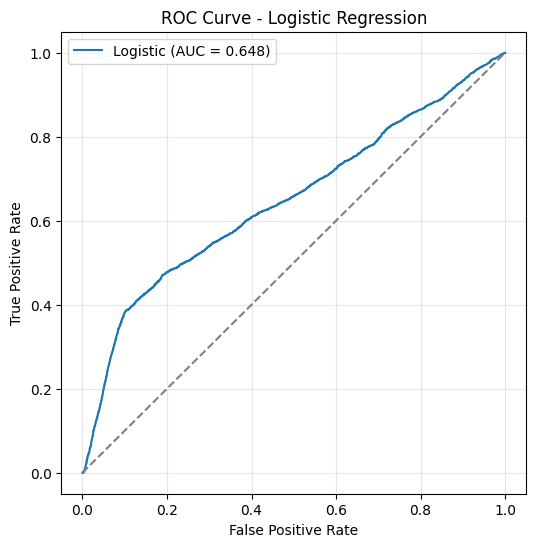

In [49]:
y_prob_log = logistic.predict_proba(X_test)[:, 1]

auc_log = roc_auc_score(y_test, y_prob_log)
print("Logistic ROC-AUC:", auc_log)

fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)

plt.figure(figsize=(6,6))
plt.plot(fpr_log, tpr_log, label=f'Logistic (AUC = {auc_log:.3f})')
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## XGBoost model
Let's use all the features for this model for best benchmarking results

In [ ]:
from xgboost import XGBClassifier

In [44]:
X_xgb = X[features].fillna(0)
y_xgb = y

X_train, X_test, y_train, y_test = train_test_split(
    X_xgb, y_xgb, test_size=0.2, random_state=42
)

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=(len(y_train) / sum(y_train)),  # handle imbalance
    eval_metric='logloss',
    random_state=42
)

xgb.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

ROC-AUC: 0.8413767299682011
Confusion Matrix:
 [[90001 23865]
 [ 1141  3101]]
              precision    recall  f1-score   support

         0.0       0.99      0.79      0.88    113866
         1.0       0.11      0.73      0.20      4242

    accuracy                           0.79    118108
   macro avg       0.55      0.76      0.54    118108
weighted avg       0.96      0.79      0.85    118108



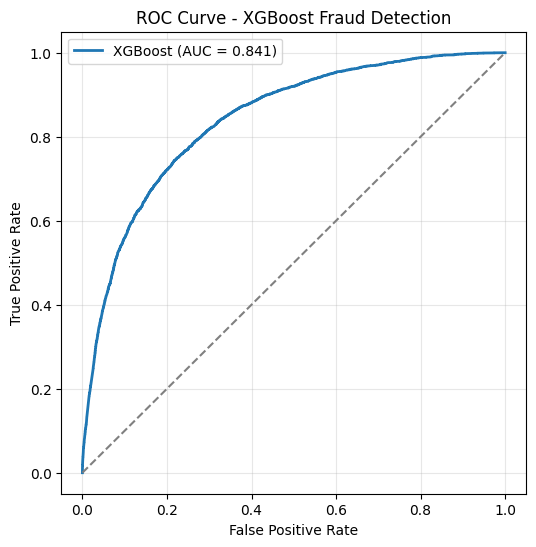

In [ ]:
y_prob = xgb.predict_proba(X_test)[:, 1]
y_pred = xgb.predict(X_test)

print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Compute ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

# Plot
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'XGBoost (AUC = {roc_auc:.3f})', linewidth=2)
plt.plot([0,1], [0,1], linestyle='--', color='gray')  # random baseline
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - XGBoost Fraud Detection')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Using the features from the v column in the dataset

In [52]:
v_features = [col for col in X.columns if col.startswith('v')]
features_with_v = features + v_features

X_xgb = X[features_with_v].fillna(0)
y_xgb = y

X_train, X_test, y_train, y_test = train_test_split(
    X_xgb, y_xgb, test_size=0.2, random_state=42
)

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=(len(y_train) / sum(y_train)),  # handle imbalance
    eval_metric='logloss',
    random_state=42
)

xgb.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

ROC-AUC: 0.8890826871090018
Confusion Matrix:
 [[96553 17313]
 [ 1007  3235]]
              precision    recall  f1-score   support

         0.0       0.99      0.85      0.91    113866
         1.0       0.16      0.76      0.26      4242

    accuracy                           0.84    118108
   macro avg       0.57      0.81      0.59    118108
weighted avg       0.96      0.84      0.89    118108



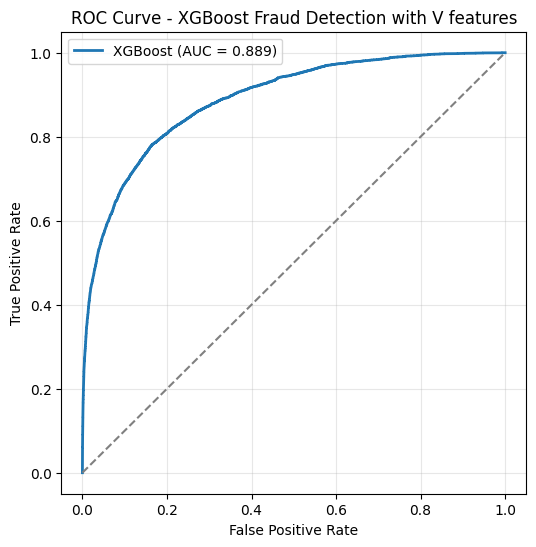

In [54]:
y_prob = xgb.predict_proba(X_test)[:, 1]
y_pred = xgb.predict(X_test)

print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Compute ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

# Plot
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'XGBoost (AUC = {roc_auc:.3f})', linewidth=2)
plt.plot([0,1], [0,1], linestyle='--', color='gray')  # random baseline
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - XGBoost Fraud Detection with V features')
plt.legend()
plt.grid(alpha=0.3)
plt.show()